# Monitoreo - Partición temporal

**Objetivo:** decidir cómo partir el dataset en el tiempo para el monitoreo de data drift, antes de escribir ningún código de `model_monitoring.py`. Una ventana de **referencia** (la "foto" contra la que se compara todo) y **períodos de monitoreo** (mes a mes, comparados contra esa referencia).

## Carga y rango de fechas

Se carga el Excel crudo con `pathlib` y se convierte `fecha_prestamo` a `datetime`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUTA_EXCEL = RAIZ / "data" / "raw" / "Base_de_datos.xlsx"

df = pd.read_excel(RUTA_EXCEL, engine="openpyxl")
df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"])

print(f"Rango completo: {df['fecha_prestamo'].min()} -> {df['fecha_prestamo'].max()}")

Rango completo: 2024-11-26 09:17:04 -> 2026-04-26 18:43:52


## Volumen de registros por mes

Se agrupa por año-mes y se grafica en barras, para ver si el volumen es parejo o hay meses con muy pocos casos (algo clave: una métrica de drift calculada sobre 10 filas no significa nada).

In [2]:
df["periodo"] = df["fecha_prestamo"].dt.to_period("M").astype(str)
conteo_mensual = df.groupby("periodo").size()
conteo_mensual

periodo
2024-11     186
2024-12    1216
2025-01    1917
2025-02    1094
2025-03    1115
2025-04    1102
2025-05    1083
2025-06     665
2025-07     644
2025-08     555
2025-09     361
2025-10     231
2025-11     166
2025-12     174
2026-01     127
2026-02      76
2026-03      40
2026-04      11
dtype: int64

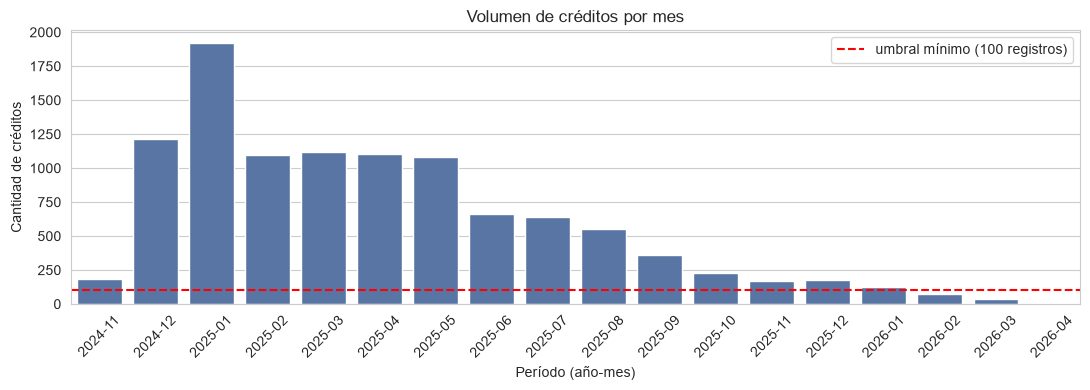

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(11, 4))
sns.barplot(x=conteo_mensual.index, y=conteo_mensual.values, color="#4C72B0")
plt.axhline(100, color="red", linestyle="--", label="umbral mínimo (100 registros)")
plt.xticks(rotation=45)
plt.ylabel("Cantidad de créditos")
plt.xlabel("Período (año-mes)")
plt.title("Volumen de créditos por mes")
plt.legend()
plt.tight_layout()
plt.show()

**Lectura.** El volumen no es parejo: arranca relativamente bajo en noviembre de 2024 (186), salta fuerte en diciembre-enero (1.216 y 1.917), y después baja de forma sostenida mes a mes desde mediados de 2025 hasta desplomarse en los últimos tres meses (76, 40 y 11 registros) — casi con certeza porque el dataset se cortó ahí, no por una caída real del negocio.

## Tasa de `Pago_atiempo` por mes

Para ver si el target también se mueve en el tiempo, no solo el volumen.

In [4]:
tasa_mensual = (df.groupby("periodo")["Pago_atiempo"].mean() * 100).round(2)
tasa_mensual

periodo
2024-11    93.01
2024-12    93.91
2025-01    95.51
2025-02    94.15
2025-03    94.89
2025-04    93.74
2025-05    95.66
2025-06    96.24
2025-07    96.89
2025-08    96.40
2025-09    98.06
2025-10    98.27
2025-11    95.78
2025-12    98.28
2026-01    94.49
2026-02    93.42
2026-03    95.00
2026-04    90.91
Name: Pago_atiempo, dtype: float64

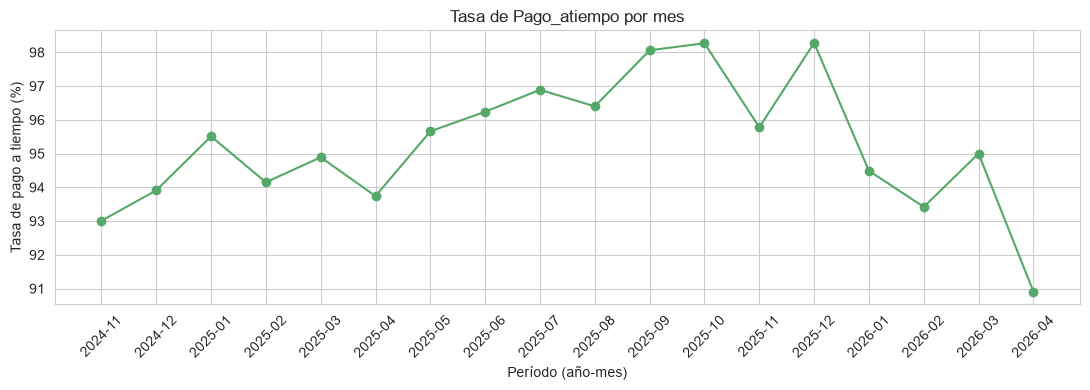

In [5]:
plt.figure(figsize=(11, 4))
plt.plot(tasa_mensual.index, tasa_mensual.values, marker="o", color="#55A868")
plt.xticks(rotation=45)
plt.ylabel("Tasa de pago a tiempo (%)")
plt.xlabel("Período (año-mes)")
plt.title("Tasa de Pago_atiempo por mes")
plt.tight_layout()
plt.show()

**Lectura.** La tasa de pago a tiempo se mueve en un rango de ~91% a ~98%, con una tendencia ascendente desde fines de 2024 (93-94%) hasta fines de 2025 (97-98%), y un poco más ruidosa (e imprecisa, por el volumen chico) en los últimos meses. Esto confirma que sí conviene monitorear: el target no es estático en el tiempo.

## Propuesta de partición

**Se descartan los meses con menos de 100 registros**, calculado abajo con código (no a ojo).

In [6]:
meses_descartados = conteo_mensual[conteo_mensual < 100]
meses_validos = conteo_mensual[conteo_mensual >= 100]

print("Meses descartados (< 100 registros):")
print(meses_descartados)
print(f"\nQuedan {len(meses_validos)} meses con >= 100 registros, de {len(conteo_mensual)} totales.")

Meses descartados (< 100 registros):
periodo
2026-02    76
2026-03    40
2026-04    11
dtype: int64

Quedan 15 meses con >= 100 registros, de 18 totales.


Los tres meses descartados (`2026-02`, `2026-03`, `2026-04`, con 76, 40 y 11 registros) son, además, los tres últimos del dataset — consistente con que el dataset se corta ahí, no con un fenómeno de negocio real. Cualquier métrica de drift calculada sobre 11 filas sería puro ruido.

**Ventana de REFERENCIA propuesta: `2024-11` a `2025-01`** (3 meses). Es la base más estable disponible: incluye el arranque del dataset con volumen ya considerable (186, 1.216 y 1.917 registros — 3.319 en total), y cubre un período donde la tasa de pago a tiempo todavía no había empezado la tendencia ascendente sostenida que se ve después — o sea, es una referencia "temprana" genuina, no una ventana elegida a mitad de una tendencia ya en curso.

**Períodos de MONITOREO propuestos: `2025-02` a `2026-01`** (12 períodos, uno por mes), todos con >= 100 registros. Da un año completo de monitoreo mes a mes, con volumen decreciente pero siempre por encima del umbral (de 1.094 en el primer período a 127 en el último).

In [7]:
FECHA_CORTE_REFERENCIA = "2025-02-01"

referencia = df[df["fecha_prestamo"] < FECHA_CORTE_REFERENCIA]
monitoreo = df[(df["fecha_prestamo"] >= FECHA_CORTE_REFERENCIA) & (df["periodo"].isin(meses_validos.index))]

print(f"Fecha de corte: {FECHA_CORTE_REFERENCIA}")
print(f"Registros en referencia: {len(referencia)}")
print(f"Períodos de monitoreo: {monitoreo['periodo'].nunique()}")
print()
print("Registros por período de monitoreo:")
print(monitoreo.groupby("periodo").size())

Fecha de corte: 2025-02-01
Registros en referencia: 3319
Períodos de monitoreo: 12

Registros por período de monitoreo:
periodo
2025-02    1094
2025-03    1115
2025-04    1102
2025-05    1083
2025-06     665
2025-07     644
2025-08     555
2025-09     361
2025-10     231
2025-11     166
2025-12     174
2026-01     127
dtype: int64


## Conclusión

- **Fecha de corte de la referencia:** `2025-02-01` (todo lo anterior a esa fecha es referencia).
- **Ventana de referencia:** `2024-11`, `2024-12`, `2025-01` — **3.319 registros**.
- **Períodos de monitoreo:** 12, de `2025-02` a `2026-01`, con tamaños que van de 1.094 (el primero) a 127 (el último).
- **Descartados:** `2026-02` (76), `2026-03` (40) y `2026-04` (11) — por debajo del umbral de 100 registros, y coinciden con la cola final del dataset.

No se escribe `model_monitoring.py` todavía: esta partición queda propuesta acá para acordarla antes de implementar nada.

# Tabla de scoring

Partición acordada. Ahora se prueba `generar_tabla_scoring` (ya escrita en `src/model_monitoring.py`): aplica `crear_features`, carga el modelo ganador, predice sobre todo el dataset y guarda el resultado en `data/processed/tabla_scoring.parquet`.

In [8]:
import sys

sys.path.insert(0, str(RAIZ))
from src.model_monitoring import generar_tabla_scoring

RUTA_MODELO = RAIZ / "models" / "modelo_final.pkl"
RUTA_TABLA_SCORING = RAIZ / "data" / "processed" / "tabla_scoring.parquet"

tabla_scoring = generar_tabla_scoring(RUTA_EXCEL, RUTA_MODELO, RUTA_TABLA_SCORING)
print("Shape:", tabla_scoring.shape)

Shape: (10763, 37)


In [9]:
tabla_scoring.head()

,tipo_credito,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje_datacredito,cant_creditosvigentes,...,sin_historial_ingresos,mes_prestamo,trimestre_prestamo,anio_prestamo,dia_semana_prestamo,fecha_prestamo,periodo,probabilidad_predicha,prediccion,Pago_atiempo
0,7,3692160.0,10,42,Independiente,8000000,2500000,341296,695.0,10,...,0,12,4,2024,5,2024-12-21 11:31:35,2024-12,0.919983,1,1
1,4,840000.0,6,60,Empleado,3000000,2000000,124876,789.0,3,...,0,4,2,2025,1,2025-04-22 09:47:35,2025-04,0.986672,1,1
2,9,5974028.4,10,36,Independiente,4036000,829000,529554,740.0,4,...,1,1,1,2026,3,2026-01-08 12:22:40,2026-01,0.824797,1,0
3,4,1671240.0,6,48,Empleado,1524547,498000,252420,837.0,4,...,0,8,3,2025,0,2025-08-04 12:04:10,2025-08,0.986752,1,1
4,9,2781636.0,11,44,Empleado,5000000,4000000,217037,771.0,4,...,0,4,2,2025,5,2025-04-26 11:24:26,2025-04,0.971015,1,1


## Distribución de `probabilidad_predicha`

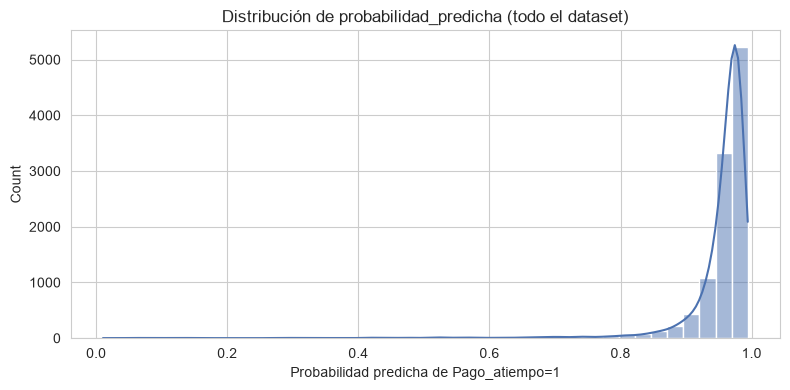

count    10763.000000
mean         0.952514
std          0.067542
min          0.010423
25%          0.950738
50%          0.968802
75%          0.979044
max          0.994137
Name: probabilidad_predicha, dtype: float64

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(tabla_scoring["probabilidad_predicha"], bins=40, kde=True, color="#4C72B0")
plt.xlabel("Probabilidad predicha de Pago_atiempo=1")
plt.title("Distribución de probabilidad_predicha (todo el dataset)")
plt.tight_layout()
plt.show()

tabla_scoring["probabilidad_predicha"].describe()

## Tasa de aprobación por período

"Tasa de aprobación" = promedio de `prediccion` (proporción de créditos que el modelo predice como "va a pagar a tiempo").

In [11]:
tasa_aprobacion = (tabla_scoring.groupby("periodo")["prediccion"].mean() * 100).round(2)
tasa_aprobacion

periodo
2024-11     98.39
2024-12     99.34
2025-01     99.43
2025-02     99.18
2025-03     99.73
2025-04     98.91
2025-05     99.91
2025-06     99.55
2025-07     99.69
2025-08     99.64
2025-09     99.72
2025-10     99.13
2025-11    100.00
2025-12    100.00
2026-01    100.00
2026-02    100.00
2026-03    100.00
2026-04    100.00
Name: prediccion, dtype: float64

# Control de las 4 métricas de drift

Las cuatro funciones (`calcular_ks`, `calcular_psi`, `calcular_jensen_shannon`, `calcular_chi2`) ya están en `src/model_monitoring.py`. Antes de usarlas en el job de monitoreo, se prueban comparando la **referencia contra sí misma**: si la implementación está bien, todas tienen que dar prácticamente 0 (o p-valor cercano a 1 para KS/chi2).

In [12]:
from src.model_monitoring import calcular_chi2, calcular_jensen_shannon, calcular_ks, calcular_psi

referencia_control = tabla_scoring[tabla_scoring["periodo"].isin(["2024-11", "2024-12", "2025-01"])]

print("=== capital_prestado (numérica) ===")
print("KS:", calcular_ks(referencia_control["capital_prestado"], referencia_control["capital_prestado"]))
print("PSI:", calcular_psi(referencia_control["capital_prestado"], referencia_control["capital_prestado"]))
print("Jensen-Shannon:", calcular_jensen_shannon(referencia_control["capital_prestado"], referencia_control["capital_prestado"]))

print("\n=== tipo_credito (categórica) ===")
print("Chi2:", calcular_chi2(referencia_control["tipo_credito"], referencia_control["tipo_credito"]))

=== capital_prestado (numérica) ===
KS: {'estadistico': 0.0, 'p_valor': 1.0}
PSI: 0.0
Jensen-Shannon: 0.0

=== tipo_credito (categórica) ===
Chi2: {'estadistico': 0.0, 'p_valor': 1.0, 'grados_libertad': 4, 'advertencia': True}


**Control OK si:** KS y PSI dan (o muy cerca de) 0, Jensen-Shannon da 0, y chi2 da estadístico ≈0 con p-valor ≈1 (ninguna diferencia entre una muestra y sí misma). Si alguno se aleja de eso, hay un error en la implementación.

# Job de monitoreo: `ejecutar_monitoreo`

Con las 4 métricas ya controladas, se corre el monitoreo completo: referencia fija (2024-11 a 2025-01) contra los 12 períodos acordados, para las columnas numéricas y categóricas que el modelo realmente usa (se excluye `puntaje` automáticamente, porque no está en `tabla_scoring`).

In [13]:
from src.ft_engineering import CATEGORICAS_NOMINALES, CATEGORICAS_ORDINALES, NUMERICAS, NUMERICAS_DERIVADAS
from src.model_monitoring import ejecutar_monitoreo

# mes_prestamo/trimestre_prestamo/anio_prestamo se excluyen del monitoreo:
# son funciones deterministas del propio período de partición (cada
# período de monitoreo ES un mes calendario), así que su PSI siempre da
# altísimo sin que sea drift real - ver la celda de abajo, donde se
# descubrió esto.
COLUMNAS_TRIVIALMENTE_ATADAS_AL_PERIODO = {"mes_prestamo", "trimestre_prestamo", "anio_prestamo"}
columnas_numericas_monitoreo = [
    c for c in NUMERICAS + NUMERICAS_DERIVADAS
    if c in tabla_scoring.columns and c not in COLUMNAS_TRIVIALMENTE_ATADAS_AL_PERIODO
]
columnas_categoricas_monitoreo = [c for c in CATEGORICAS_NOMINALES + CATEGORICAS_ORDINALES if c in tabla_scoring.columns]

print("Numéricas monitoreadas:", len(columnas_numericas_monitoreo))
print("Categóricas monitoreadas:", len(columnas_categoricas_monitoreo))
print("¿'puntaje' quedó afuera?:", "puntaje" not in columnas_numericas_monitoreo)

RUTA_HISTORICO = RAIZ / "data" / "processed" / "historico_drift.csv"
historico_drift = ejecutar_monitoreo(
    tabla_scoring, FECHA_CORTE_REFERENCIA, columnas_numericas_monitoreo, columnas_categoricas_monitoreo, RUTA_HISTORICO,
)
print(f"\nShape del histórico: {historico_drift.shape}")
print(f"Períodos procesados: {sorted(historico_drift['periodo'].unique())}")

Numéricas monitoreadas: 26
Categóricas monitoreadas: 3
¿'puntaje' quedó afuera?: True


[model_monitoring] período 2026-02 salteado: 76 registros (< 100 mínimo).
[model_monitoring] período 2026-03 salteado: 40 registros (< 100 mínimo).
[model_monitoring] período 2026-04 salteado: 11 registros (< 100 mínimo).

Shape del histórico: (1008, 8)
Períodos procesados: ['2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01']


## Top 15 combinaciones período+variable con mayor PSI

In [14]:
historico_drift[historico_drift["metrica"] == "PSI"].sort_values("valor", ascending=False).head(15)

,periodo,variable,tipo_variable,metrica,valor,p_valor,n_referencia,n_actual
889,2025-12,promedio_ingresos_datacredito,numerica,PSI,1.353999,NaN,3319,174
553,2025-08,promedio_ingresos_datacredito,numerica,PSI,1.247870,NaN,3319,555
637,2025-09,promedio_ingresos_datacredito,numerica,PSI,1.227166,NaN,3319,361
721,2025-10,promedio_ingresos_datacredito,numerica,PSI,1.206625,NaN,3319,231
973,2026-01,promedio_ingresos_datacredito,numerica,PSI,1.086509,NaN,3319,127
340,2025-06,plazo_meses,numerica,PSI,0.843993,NaN,3319,665
508,2025-08,plazo_meses,numerica,PSI,0.737367,NaN,3319,555
424,2025-07,plazo_meses,numerica,PSI,0.721095,NaN,3319,644
844,2025-12,plazo_meses,numerica,PSI,0.702006,NaN,3319,174
301,2025-05,promedio_ingresos_datacredito,numerica,PSI,0.685799,NaN,3319,1083


**Hallazgo antes de aceptar este top 15: `mes_prestamo` (y por construcción `trimestre_prestamo`/`anio_prestamo`) dominaban el ranking con PSI absurdo (4.86-9.10)** — no es drift real, es que cada período de monitoreo ES un mes calendario, así que la distribución de `mes_prestamo` en cualquier período es un pico en un solo valor, siempre distinto al de la referencia (que mezcla tres meses). Son variables trivialmente "en drift" por construcción, no por ningún cambio real en la población. Se excluyeron del monitoreo (quedan como columnas en `crear_features`, se siguen calculando, pero no se pasan a `ejecutar_monitoreo`) — el código y el motivo quedan documentados arriba. Con esa exclusión, la variable que de verdad encabeza el ranking es `promedio_ingresos_datacredito` (PSI 1.23-1.35 en varios períodos de fin de 2025), que sí es una señal legítima a investigar.

# Capa de interpretación: `UMBRALES`, `clasificar_severidad`, `generar_recomendaciones`

Ya están en `src/model_monitoring.py`. Se corre `generar_recomendaciones` sobre el histórico real recién calculado.

In [15]:
from src.model_monitoring import UMBRALES, clasificar_severidad, generar_recomendaciones

print("UMBRALES:", UMBRALES)
print()

recomendaciones = generar_recomendaciones(historico_drift)
for mensaje in recomendaciones:
    print(mensaje)
    print()

UMBRALES: {'PSI': {'moderado': 0.1, 'significativo': 0.25}, 'Jensen-Shannon': {'moderado': 0.1, 'significativo': 0.2}, 'KS': {'p_valor_significativo': 0.05}, 'Chi2': {'p_valor_significativo': 0.05}}

🔴 Reentrenamiento completo recomendado: en el período 2026-01 hay 13 variables en rojo (capital_prestado, carga_total, cuota_pactada, diferencia_ingresos, plazo_meses, probabilidad_predicha, promedio_ingresos_datacredito, puntaje_datacredito, ratio_cuota_salario, ratio_endeudamiento, ratio_ingresos_declarados, salario_cliente, total_otros_prestamos). Con tantas variables fuera de rango a la vez, ajustar el modelo variable por variable ya no alcanza — conviene reentrenar con una ventana de datos que incluya 2026-01 en adelante.

🟡 Deterioro sostenido en 'capital_prestado': viene en amarillo o rojo desde 2025-04 hasta 2025-06 (3 períodos consecutivos). Revisar el proceso de originación/captura de esta variable en ese rango de fechas antes de que siga empeorando.

🟡 Deterioro sostenido en 'ca

**Antes de aceptar esta lista de recomendaciones: hay que leerla con la cantidad de observaciones al lado, como dice la regla del proyecto.** El PSI promedio de todas las numéricas sube de forma casi monótona a medida que avanza el tiempo — y a medida que **baja** el tamaño de muestra del período: 0.03 en `2025-02` (n=1.094) hasta 0.19-0.23 en los últimos períodos (n=127-231). Dos cosas están mezcladas ahí:

- **Hay drift real**, no es solo ruido: ya en los primeros períodos, con muestras grandes (1.000+ registros, donde el ruido de bins no explica mucho), el PSI promedio sube de 0.03 a 0.07-0.10 — una tendencia genuina, no casualidad de muestra chica.
- **Pero la amplificación en los últimos períodos es sospechosa**: con solo 127-231 registros repartidos en 10 bins (12-23 observaciones por bin), cualquier variable va a mostrar más ruido de estimación, así que la lista larga de "deterioro sostenido" que salió de `generar_recomendaciones` para los períodos de fin de 2025 probablemente mezcla drift real con ruido de muestra chica en partes similares. La regla de "≥100 registros" (acordada al definir la partición) evita el caso extremo, pero no elimina el problema — 127 sigue siendo poco para un PSI de 10 bins.

Esto queda documentado para la app: cualquier alerta de un período con `n_actual` chico (compararlo contra los ~3.300 de la referencia) debería mostrarse con esa salvedad visible, no como una alerta con la misma confianza que una calculada sobre 1.000+ registros.